<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1/scratch_cnn_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# STEP 1: Imports and GPU check**

In [ ]:

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


GPU available: True
GPU name: Tesla T4
Using device: cuda


**# STEP 2: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


**# STEP 3: Extract dataset zip files**

In [ ]:
dataset_path = "/content/drive/MyDrive/compx525assign1/cell_cultures"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

for f in os.listdir(dataset_path):
    if f.endswith(".zip"):
        zip_path = os.path.join(dataset_path, f)
        print("Extracting:", zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print("Extraction complete")
print("Extracted folders:", os.listdir(extract_path))



Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Extraction complete
Extracted folders: ['train', 'test']


**# STEP 4: DEFINE TRAIN AND TEST PATHS**

In [ ]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
image_exts = (".jpg", ".jpeg", ".png")

classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Folder classes:", classes)
print("Number of folder classes:", len(classes))

print("Usable image counts per class:")
for c in classes:
    cls_path = os.path.join(train_dir, c)
    count = sum(fname.lower().endswith(image_exts) for fname in os.listdir(cls_path))
    print(c, count)

print("Test images:", len([f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]))


Folder classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of folder classes: 17
Usable image counts per class:
a 1283
b 4
c 475
d 266
e 117
f 59
g 720
h 5
i 199
j 0
k 12
l 660
m 543
n 91
o 197
p 35
q 29
Test images: 512


**# STEP 5: Set train/test paths and count usable images**

In [ ]:
rows = []

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(image_exts):
                rows.append({
                    "filepath": os.path.join(cls_path, fname),
                    "label": cls
                })

train_df = pd.DataFrame(rows)

print(train_df.head())
print("\nTotal usable training images:", len(train_df))
print("\nUsable class counts:")
print(train_df["label"].value_counts().sort_index())

                                   filepath label
0   /content/dataset/train/a/z218573767.jpg     a
1  /content/dataset/train/a/z1813342289.jpg     a
2   /content/dataset/train/a/z868447228.jpg     a
3     /content/dataset/train/a/z2971842.jpg     a
4   /content/dataset/train/a/z670494583.jpg     a

Total usable training images: 4695

Usable class counts:
label
a    1283
b       4
c     475
d     266
e     117
f      59
g     720
h       5
i     199
k      12
l     660
m     543
n      91
o     197
p      35
q      29
Name: count, dtype: int64


**# STEP 6: TRAIN / VALIDATION SPLIT**

In [ ]:

class_counts = train_df["label"].value_counts()

# Classes with < 15 images go to training only — too few images for a reliable val split
# (mirrors the DINOv2 notebook strategy; original only excluded singletons < 2)
EXTREME_CLASSES = class_counts[class_counts < 15].index.tolist()
extreme_df  = train_df[train_df["label"].isin(EXTREME_CLASSES)].copy()
normal_df   = train_df[~train_df["label"].isin(EXTREME_CLASSES)].copy()

train_split_df, val_split_df = train_test_split(
    normal_df,
    test_size=0.2,
    stratify=normal_df["label"],
    random_state=42
)

# Extreme-minority classes added back to training only (never validation)
train_split_df = pd.concat([train_split_df, extreme_df], ignore_index=True)

print("Extreme minority classes (train only, <15 images):", EXTREME_CLASSES)
print("Train size (before oversample):", len(train_split_df))
print("Val size:", len(val_split_df))
print("\nTrain split class counts:")
print(train_split_df["label"].value_counts().sort_index())
print("\nVal split class counts:")
print(val_split_df["label"].value_counts().sort_index())


Train size: 3756
Val size: 939

Train split class counts:
label
a    1026
b       3
c     380
d     213
e      94
f      47
g     576
h       4
i     159
k      10
l     528
m     434
n      73
o     158
p      28
q      23
Name: count, dtype: int64

Val split class counts:
label
a    257
b      1
c     95
d     53
e     23
f     12
g    144
h      1
i     40
k      2
l    132
m    109
n     18
o     39
p      7
q      6
Name: count, dtype: int64


In [ ]:

# STEP 6b: Oversample extreme minority classes to ~120 appearances per epoch
# Each appearance gets a different random augmentation, creating genuine diversity
EXTREME_TARGET = 120

parts = []
for cls, grp in train_split_df.groupby("label"):
    if cls in EXTREME_CLASSES:
        repeats = max(1, EXTREME_TARGET // len(grp))
        repeated = pd.concat([grp] * repeats, ignore_index=True)
        parts.append(repeated)
        print(f"  [{cls}] {len(grp)} images -> {len(repeated)} rows (x{repeats} oversample)")
    else:
        parts.append(grp)

train_split_df = (
    pd.concat(parts, ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"\nTrain size after oversample: {len(train_split_df)}")
print("Class counts after oversample:")
print(train_split_df["label"].value_counts().sort_index())


**# STEP 7: ENCODE LABELS**

In [ ]:
label_to_idx = {
    label: idx for idx, label in enumerate(sorted(train_df["label"].unique()))
}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

effective_classes = sorted(label_to_idx.keys())
print("Usable classes:", effective_classes)
print("Number of usable classes:", len(effective_classes))
print("label_to_idx:", label_to_idx)

train_split_df["label_idx"] = train_split_df["label"].map(label_to_idx)
val_split_df["label_idx"] = val_split_df["label"].map(label_to_idx)

print(train_split_df.head())
print(val_split_df.head())

Usable classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of usable classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}
                                   filepath label  label_idx
0  /content/dataset/train/l/z1728134539.jpg     l         10
1   /content/dataset/train/a/z461066921.jpg     a          0
2   /content/dataset/train/i/z850361057.jpg     i          8
3   /content/dataset/train/a/z275939099.jpg     a          0
4   /content/dataset/train/a/z365386909.jpg     a          0
                                      filepath label  label_idx
2879   /content/dataset/train/g/z601380699.jpg     g          6
3435  /content/dataset/train/l/z1765107073.jpg     l         10
2157  /content/dataset/train/f/z1998937689.jpg     f          5
2346   /content/dataset/train/g/z940782865.jpg     g          6
2367    /content/dataset/train/g/z80764

**# STEP 8: ScratchCNN transforms**

In [ ]:

# Standard training augmentation for all non-extreme classes
scratch_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),   # scale diversity; replaces plain Resize
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),                  # safe for microscopy — no canonical top
    transforms.RandomRotation(45),                         # was 10; 45 is safe for cell images
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15),  # stain variation
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),            # focus variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Heavier augmentation for extreme-minority classes — maximise diversity from few images
extreme_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation: deterministic, no augmentation
scratch_val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


**# STEP 9: ScratchCNN datasets and loaders**

In [ ]:

class ImageDataset(Dataset):
    def __init__(self, df, transform=None, extreme_transform=None, extreme_classes=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.extreme_transform = extreme_transform
        self.extreme_classes = set(extreme_classes or [])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label    = self.df.loc[idx, "label_idx"]
        image    = Image.open(img_path).convert("RGB")

        if self.df.loc[idx, "label"] in self.extreme_classes and self.extreme_transform is not None:
            image = self.extreme_transform(image)
        elif self.transform is not None:
            image = self.transform(image)

        return image, label


scratch_train_dataset = ImageDataset(
    train_split_df,
    transform=scratch_train_transform,
    extreme_transform=extreme_train_transform,
    extreme_classes=EXTREME_CLASSES,
)
scratch_val_dataset = ImageDataset(val_split_df, transform=scratch_val_transform)

scratch_train_loader = DataLoader(scratch_train_dataset, batch_size=32, shuffle=True,
                                  num_workers=2, pin_memory=True)
scratch_val_loader   = DataLoader(scratch_val_dataset,   batch_size=32, shuffle=False,
                                  num_workers=2, pin_memory=True)

print("Scratch train dataset size:", len(scratch_train_dataset))
print("Scratch val dataset size:  ", len(scratch_val_dataset))


Scratch train dataset size: 3756
Scratch val dataset size: 939


**# STEP 10: define and create ScratchCNN class**

In [ ]:

class ScratchCNN(nn.Module):
    def __init__(self, num_classes):
        super(ScratchCNN, self).__init__()

        # Feature extractor — BatchNorm added after every Conv to stabilise training
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # GlobalAveragePooling replaces the original Linear(256*14*14=50176, 512) layer
        # which had ~25.7M parameters — far too many for a small dataset (severe overfitting)
        # GAP reduces each 256-channel map to a single value: 256 dims total
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_avg_pool(x)
        x = self.classifier(x)
        return x


scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

print(scratch_model)
print(f"\nTotal params: {sum(p.numel() for p in scratch_model.parameters()):,}")
print("Device:", device)


ScratchCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=16, bias=True)
  )


**# STEP 11: define scratch_criterion and scratch_optimizer**

In [ ]:

# Class-weighted CrossEntropyLoss — sqrt weighting softens the effect of
# oversampled minority rows while still directing the model toward rare classes.
# Original used unweighted CE which silently ignores rare classes.
counts = train_split_df["label_idx"].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(counts.values, dtype=torch.float).sqrt()
class_weights = (class_weights / class_weights.sum() * len(label_to_idx)).to(device)
print("Class weights:", class_weights)

scratch_criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam with weight_decay=1e-4 — adds L2 regularisation.
# Original had weight_decay=0 (default), which combined with the 25M-param FC
# meant zero penalty for memorisation.
scratch_optimizer = optim.Adam(
    scratch_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4,
)

# ReduceLROnPlateau halves the LR when val acc doesn't improve for 3 epochs.
# Original had no scheduler — the LR stayed fixed for all 15 epochs.
scratch_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    scratch_optimizer, mode="max", factor=0.5, patience=3,
)

print("\nLoss function:", scratch_criterion)
print("Optimizer:", scratch_optimizer)
print("Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=3)")


Scratch model loss function:
CrossEntropyLoss()

Scratch model optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0
)


**# STEP 12: train ScratchCNN using scratch_train_loader and scratch_val_loader**

In [ ]:

scratch_best_path = "/content/drive/MyDrive/scratchcnn_improved_best.pth"

best_scratch_val_acc = 0.0
num_epochs = 15

for epoch in range(num_epochs):
    # -------------------------
    # TRAINING PHASE
    # -------------------------
    scratch_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(scratch_train_loader):
        images = images.to(device)
        labels = labels.to(device)

        scratch_optimizer.zero_grad()
        outputs = scratch_model(images)
        loss = scratch_criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — prevents gradient spikes that destabilise training.
        # Without this a single bad batch can undo many epochs of learning.
        torch.nn.utils.clip_grad_norm_(scratch_model.parameters(), max_norm=1.0)

        scratch_optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(f"ScratchCNN | Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(scratch_train_loader)}")

    train_loss = running_loss / len(scratch_train_loader)
    train_acc  = train_correct / train_total

    # -------------------------
    # VALIDATION PHASE
    # -------------------------
    scratch_model.eval()
    val_correct = 0
    val_total   = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for images, labels in scratch_val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = scratch_model(images)
            val_loss_total += scratch_criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc  = val_correct / val_total
    val_loss = val_loss_total / len(scratch_val_loader)
    current_lr = scratch_optimizer.param_groups[0]["lr"]

    # Step the LR scheduler based on val accuracy
    scratch_scheduler.step(val_acc)

    if val_acc > best_scratch_val_acc:
        best_scratch_val_acc = val_acc
        torch.save(
            {
                "model_state_dict": scratch_model.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "best_val_acc": best_scratch_val_acc,
            },
            scratch_best_path,
        )
        print(f"  --> Saved new best model at epoch {epoch+1} (val_acc={val_acc:.4f})")

    print(
        f"ScratchCNN | Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}"
    )

print("\nBest ScratchCNN validation accuracy:", best_scratch_val_acc)
print("Best model saved to:", scratch_best_path)


ScratchCNN | Epoch 1/15 | Batch 20/118
ScratchCNN | Epoch 1/15 | Batch 40/118
ScratchCNN | Epoch 1/15 | Batch 60/118
ScratchCNN | Epoch 1/15 | Batch 80/118
ScratchCNN | Epoch 1/15 | Batch 100/118
Saved new best ScratchCNN model at epoch 1
ScratchCNN | Epoch 1/15 | Train Loss: 2.1380 | Train Acc: 0.2926 | Val Acc: 0.3504
ScratchCNN | Epoch 2/15 | Batch 20/118
ScratchCNN | Epoch 2/15 | Batch 40/118
ScratchCNN | Epoch 2/15 | Batch 60/118
ScratchCNN | Epoch 2/15 | Batch 80/118
ScratchCNN | Epoch 2/15 | Batch 100/118
Saved new best ScratchCNN model at epoch 2
ScratchCNN | Epoch 2/15 | Train Loss: 1.9603 | Train Acc: 0.3498 | Val Acc: 0.3685
ScratchCNN | Epoch 3/15 | Batch 20/118
ScratchCNN | Epoch 3/15 | Batch 40/118
ScratchCNN | Epoch 3/15 | Batch 60/118
ScratchCNN | Epoch 3/15 | Batch 80/118
ScratchCNN | Epoch 3/15 | Batch 100/118
Saved new best ScratchCNN model at epoch 3
ScratchCNN | Epoch 3/15 | Train Loss: 1.8462 | Train Acc: 0.3818 | Val Acc: 0.4058
ScratchCNN | Epoch 4/15 | Batch 20

**#STEP 13: EVALUATE BEST ScratchCNN ON VALIDATION SET**

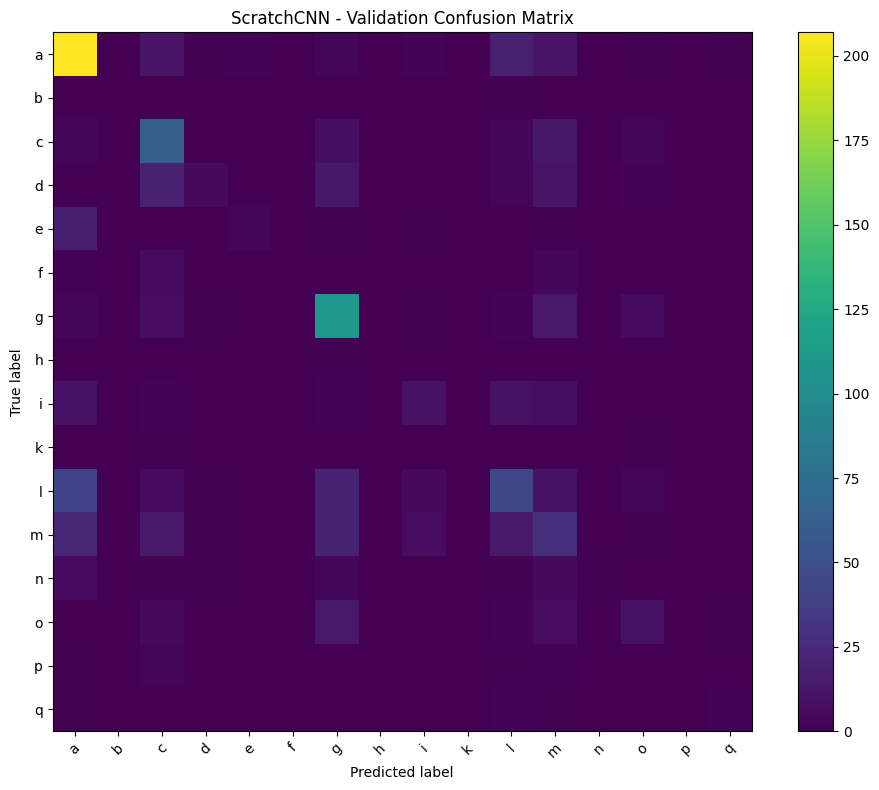

              precision    recall  f1-score   support

           a       0.66      0.81      0.72       257
           b       0.00      0.00      0.00         1
           c       0.46      0.66      0.54        95
           d       0.50      0.09      0.16        53
           e       0.60      0.13      0.21        23
           f       0.00      0.00      0.00        12
           g       0.56      0.76      0.65       144
           h       0.00      0.00      0.00         1
           i       0.36      0.23      0.28        40
           k       0.00      0.00      0.00         2
           l       0.43      0.33      0.38       132
           m       0.25      0.27      0.26       109
           n       1.00      0.06      0.11        18
           o       0.36      0.26      0.30        39
           p       0.00      0.00      0.00         7
           q       0.50      0.33      0.40         6

    accuracy                           0.51       939
   macro avg       0.35   

In [ ]:
# Rebuild the ScratchCNN model structure
scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

# Load the best saved ScratchCNN model
checkpoint_path = "/content/drive/MyDrive/scratchcnn_E_lowlr_best2.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
scratch_model.load_state_dict(checkpoint["model_state_dict"])

# Put model in evaluation mode
scratch_model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in scratch_val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = scratch_model(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

# Build confusion matrix
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("ScratchCNN - Validation Confusion Matrix")
plt.colorbar()

class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(
    all_true,
    all_pred,
    target_names=class_names,
    zero_division=0
))

**# STEP 15: CREATE TEST DATAFRAME AND TEST DATALOADER**



In [ ]:
test_rows = []

for fname in sorted(os.listdir(test_dir)):
    if fname.lower().endswith(image_exts):
        test_rows.append({
            "filepath": os.path.join(test_dir, fname),
            "filename": fname
        })

test_df = pd.DataFrame(test_rows)
print(test_df.head())
print("Total test images:", len(test_df))


class TestImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        filename = self.df.loc[idx, "filename"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, filename


test_dataset = TestImageDataset(test_df, transform=scratch_val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test dataset size:", len(test_dataset))

                                filepath         filename
0    /content/dataset/test/z10002793.jpg    z10002793.jpg
1  /content/dataset/test/z1002467769.jpg  z1002467769.jpg
2  /content/dataset/test/z1002525907.jpg  z1002525907.jpg
3  /content/dataset/test/z1004350237.jpg  z1004350237.jpg
4   /content/dataset/test/z100756404.jpg   z100756404.jpg
Total test images: 512
Test dataset size: 512


**# STEP 16: CREATE TEST CSV USING BEST ScratchCNN MODEL**

In [ ]:
# Rebuild ScratchCNN
scratch_model = ScratchCNN(num_classes=len(label_to_idx))
scratch_model = scratch_model.to(device)

# Load best saved ScratchCNN model
checkpoint_path = "/content/drive/MyDrive/scratchcnn_E_lowlr_best2.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)
scratch_model.load_state_dict(checkpoint["model_state_dict"])

# Evaluation mode
scratch_model.eval()

all_filenames = []
all_pred_labels = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = scratch_model(images)
        _, preds = torch.max(outputs, 1)

        pred_labels = [idx_to_label[p.item()] for p in preds]

        all_filenames.extend(filenames)
        all_pred_labels.extend(pred_labels)

scratch_submission_df = pd.DataFrame({
    "TestFileName": all_filenames,
    "Class": all_pred_labels
})

scratch_csv_path = "/content/drive/MyDrive/scratchcnn_E_lowlr_submission2.csv"
scratch_submission_df.to_csv(scratch_csv_path, index=False)

print(scratch_submission_df.head())
print("Saved to:", scratch_csv_path)

      TestFileName Class
0    z10002793.jpg     a
1  z1002467769.jpg     a
2  z1002525907.jpg     a
3  z1004350237.jpg     c
4   z100756404.jpg     i
Saved to: /content/drive/MyDrive/scratchcnn_E_lowlr_submission2.csv
